<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
file_path = '/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the dataset
display(df.head())

,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


Now, let's get a summary of the dataset's information, including column data types and non-null values.

In [ ]:
# Identify outliers in residuals for the 80:20 split using IQR method

Q1 = residuals_80.quantile(0.25)
Q3 = residuals_80.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_residuals_80 = residuals_80[(residuals_80 < lower_bound) | (residuals_80 > upper_bound)]

print(f"Number of outliers in residuals (80:20 split): {len(outlier_residuals_80)}")
print("\nStatistics for outlier residuals:")
display(outlier_residuals_80.describe())

# Display the actual values, predicted values, and residuals for some of the outliers
print("\nDetails of some outlier predictions (Actual, Predicted, Residual):")
outlier_indices = outlier_residuals_80.index
outlier_data = pd.DataFrame({
    'Actual_Load': y_test_80.loc[outlier_indices],
    'Predicted_Load': pd.Series(y_pred_80, index=y_test_80.index).loc[outlier_indices],
    'Residual': outlier_residuals_80
})
display(outlier_data.head())

Number of outliers in residuals (80:20 split): 202

Statistics for outlier residuals:


,Load
count,202.000000
mean,95.842785
std,245.775117
min,-1238.743600
25%,80.013750
50%,105.867300
75%,166.855050
max,1573.513200



Details of some outlier predictions (Actual, Predicted, Residual):


,Actual_Load,Predicted_Load,Residual
5273,115.868,32.6700,83.1980
1263,422.997,222.4818,200.5152
4707,365.850,496.4862,-130.6362
4907,259.850,145.0052,114.8448
982,210.440,74.5622,135.8778


### Strategies for Handling Outliers

Outliers can significantly impact model training and evaluation. Here are some common strategies to handle them:

1.  **Removal (Trimming)**: Removing the outlier data points entirely. This is suitable if outliers are due to data entry errors or anomalies that are not representative of the true data distribution. However, it can lead to loss of valuable information if the outliers are genuine, and it's generally not recommended to remove outliers from the test set for evaluation purposes as it can make the model appear better than it is.

2.  **Capping/Winsorization**: Replacing outliers with a specific value, often the maximum or minimum non-outlier value (e.g., values beyond the 95th percentile are replaced with the 95th percentile value). This reduces the impact of extreme values without removing them entirely.

3.  **Transformation**: Applying mathematical transformations (e.g., log, square root) to the data to reduce the skewness caused by outliers, making the distribution more normal. This can make the data more amenable to certain models.

4.  **Imputation**: If outliers are suspected to be erroneous entries, they can sometimes be treated as missing values and imputed using methods like mean, median, or more sophisticated techniques.

5.  **Robust Models**: Using models that are less sensitive to outliers (e.g., tree-based models like Random Forest or Gradient Boosting, or Huber Regressor).

For the identified outliers in the 80:20 split residuals, we will first demonstrate the impact of removing them from the test set on the evaluation metrics. Then, we will explore applying a capping strategy on the original `Load` column before model training.

### 1. Handling Outliers by Removal from Test Set (for Impact Analysis)

To understand the impact of these specific outliers on the model's performance, we can create a filtered test set where these outlier data points (identified by their residuals) are removed. We'll then re-evaluate the model on this filtered set. Note that this is primarily for analysis to see 'what if' these points weren't present, and not a standard practice for deploying models, as a real-world test set should ideally represent the true data distribution including anomalies.

In [ ]:
# Get the indices of the outlier residuals from the 80:20 split
outlier_indices_80 = outlier_residuals_80.index

# Create a filtered version of y_test_80 and y_pred_80 by dropping outlier indices
y_test_80_filtered = y_test_80.drop(outlier_indices_80)
y_pred_80_filtered = pd.Series(y_pred_80, index=y_test_80.index).drop(outlier_indices_80)

# Re-evaluate the model on the filtered 80:20 test set
mae_80_filtered = mean_absolute_error(y_test_80_filtered, y_pred_80_filtered)
mse_80_filtered = mean_squared_error(y_test_80_filtered, y_pred_80_filtered)
rmse_80_filtered = np.sqrt(mse_80_filtered)
r2_80_filtered = r2_score(y_test_80_filtered, y_pred_80_filtered)

# Create a DataFrame to display results
filtered_results_df = pd.DataFrame({
    'Split Ratio': ['80:20 (Original)', '80:20 (Outliers Removed from Test Set)'],
    'MAE': [mae_80, mae_80_filtered],
    'MSE': [mse_80, mse_80_filtered],
    'RMSE': [rmse_80, rmse_80_filtered],
    'R2 Score': [r2_80, r2_80_filtered]
})

print("--- Model Evaluation Results (with and without outlier residuals) ---")
display(filtered_results_df)

print(f"Number of data points in original 80:20 test set: {len(y_test_80)}")
print(f"Number of data points in filtered 80:20 test set (outliers removed): {len(y_test_80_filtered)}")

--- Model Evaluation Results (with and without outlier residuals) ---


,Split Ratio,MAE,MSE,RMSE,R2 Score
0,80:20 (Original),40.613678,9014.532579,94.944892,0.966933
1,80:20 (Outliers Removed from Test Set),19.879957,703.207629,26.518062,0.984824


Number of data points in original 80:20 test set: 1667
Number of data points in filtered 80:20 test set (outliers removed): 1465


### 2. Handling Outliers by Capping the Original 'Load' Column

A more common approach to handle outliers as a preprocessing step is to cap them in the original dataset. We will use the Interquartile Range (IQR) method to define upper and lower bounds, and then replace any values outside these bounds with the bound values. After capping, we'll re-run the entire 80:20 modeling pipeline to see the effect on the model's performance.

### Visualizing the Impact of Outlier Removal from Test Set

/tmp/ipykernel_532/1516711316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split Ratio', y='MAE', data=filtered_results_df, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_532/1516711316.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split Ratio', y='MSE', data=filtered_results_df, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_532/1516711316.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split Ratio', y='RMSE', data=filtered_results_df, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_532/1516711316.py:17: Futu

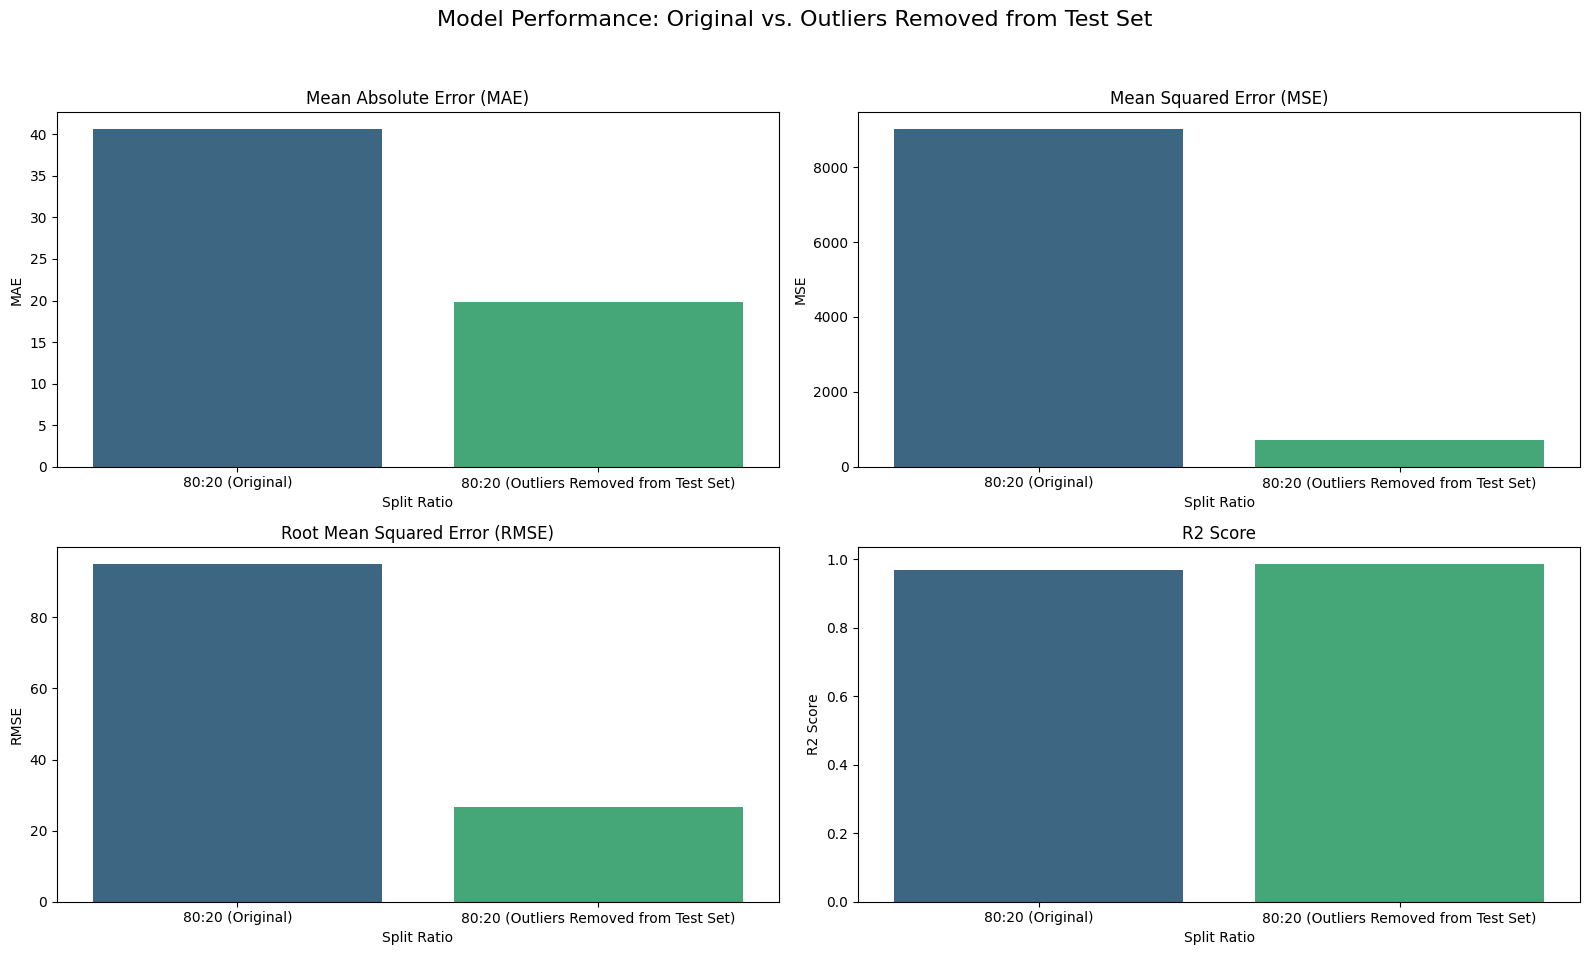

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance: Original vs. Outliers Removed from Test Set', fontsize=16)

# MAE
sns.barplot(x='Split Ratio', y='MAE', data=filtered_results_df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Mean Absolute Error (MAE)')

# MSE
sns.barplot(x='Split Ratio', y='MSE', data=filtered_results_df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Mean Squared Error (MSE)')

# RMSE
sns.barplot(x='Split Ratio', y='RMSE', data=filtered_results_df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Root Mean Squared Error (RMSE)')

# R2 Score
sns.barplot(x='Split Ratio', y='R2 Score', data=filtered_results_df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('R2 Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualizing the Impact of Capping 'Load' Column

### Model Evaluation Results (with and without outlier residuals)

In [ ]:
display(filtered_results_df)

,Split Ratio,MAE,MSE,RMSE,R2 Score
0,80:20 (Original),40.613678,9014.532579,94.944892,0.966933
1,80:20 (Outliers Removed from Test Set),19.879957,703.207629,26.518062,0.984824


### Model Evaluation Results (Original vs. Capped Load)

### Model Evaluation Results for Different Split Ratios

In [ ]:
display(results_df)

,Split Ratio,MAE,MSE,RMSE,R2 Score
0,80:20,40.613678,9014.532579,94.944892,0.966933
1,70:30,40.786249,8440.138601,91.870227,0.965785


### Visualizing Performance Metrics for Different Split Ratios

/tmp/ipykernel_532/1316036219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split Ratio', y='MAE', data=results_df, ax=axes[0, 0], palette='coolwarm')
/tmp/ipykernel_532/1316036219.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split Ratio', y='MSE', data=results_df, ax=axes[0, 1], palette='coolwarm')
/tmp/ipykernel_532/1316036219.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split Ratio', y='RMSE', data=results_df, ax=axes[1, 0], palette='coolwarm')
/tmp/ipykernel_532/1316036219.py:17: FutureWarning: 

Passing `pa

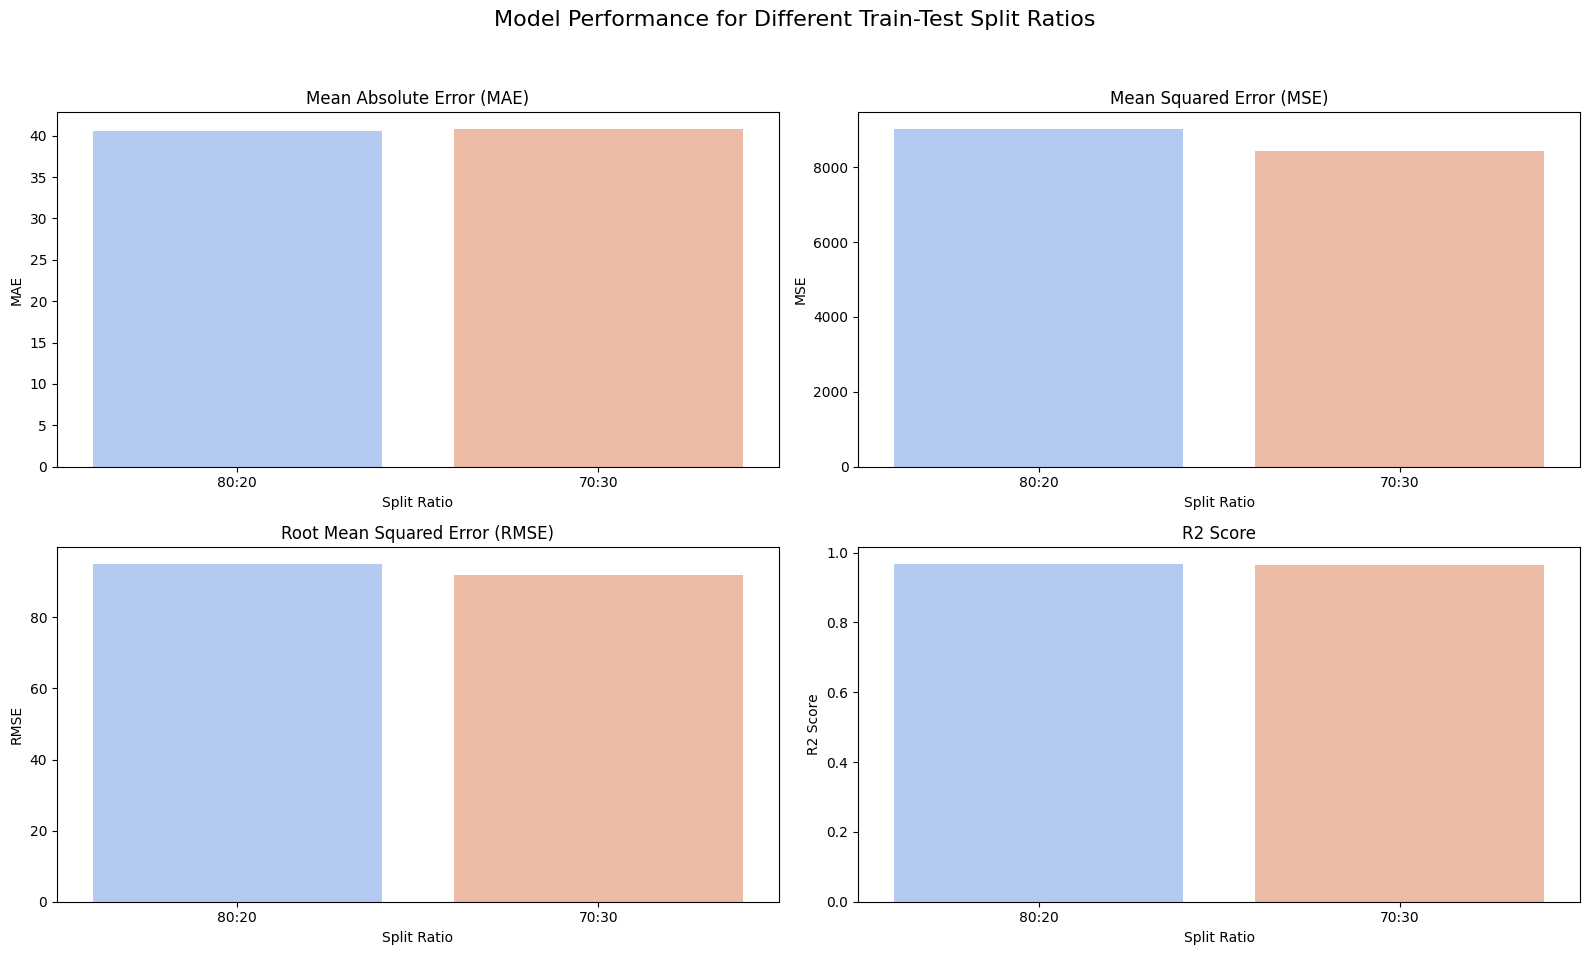

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance for Different Train-Test Split Ratios', fontsize=16)

# MAE
sns.barplot(x='Split Ratio', y='MAE', data=results_df, ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Mean Absolute Error (MAE)')

# MSE
sns.barplot(x='Split Ratio', y='MSE', data=results_df, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Mean Squared Error (MSE)')

# RMSE
sns.barplot(x='Split Ratio', y='RMSE', data=results_df, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Root Mean Squared Error (RMSE)')

# R2 Score
sns.barplot(x='Split Ratio', y='R2 Score', data=results_df, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('R2 Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
display(capped_results_df)

,Scenario,MAE,MSE,RMSE,R2 Score
0,Original (80:20 Split),40.613678,9014.532579,94.944892,0.966933
1,Capped Load (80:20 Split),22.156418,1121.876442,33.494424,0.755038


/tmp/ipykernel_532/337553869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scenario', y='MAE', data=capped_results_df, ax=axes[0, 0], palette='magma')
/tmp/ipykernel_532/337553869.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scenario', y='MSE', data=capped_results_df, ax=axes[0, 1], palette='magma')
/tmp/ipykernel_532/337553869.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scenario', y='RMSE', data=capped_results_df, ax=axes[1, 0], palette='magma')
/tmp/ipykernel_532/337553869.py:17: FutureWarning: 

Passing `pal

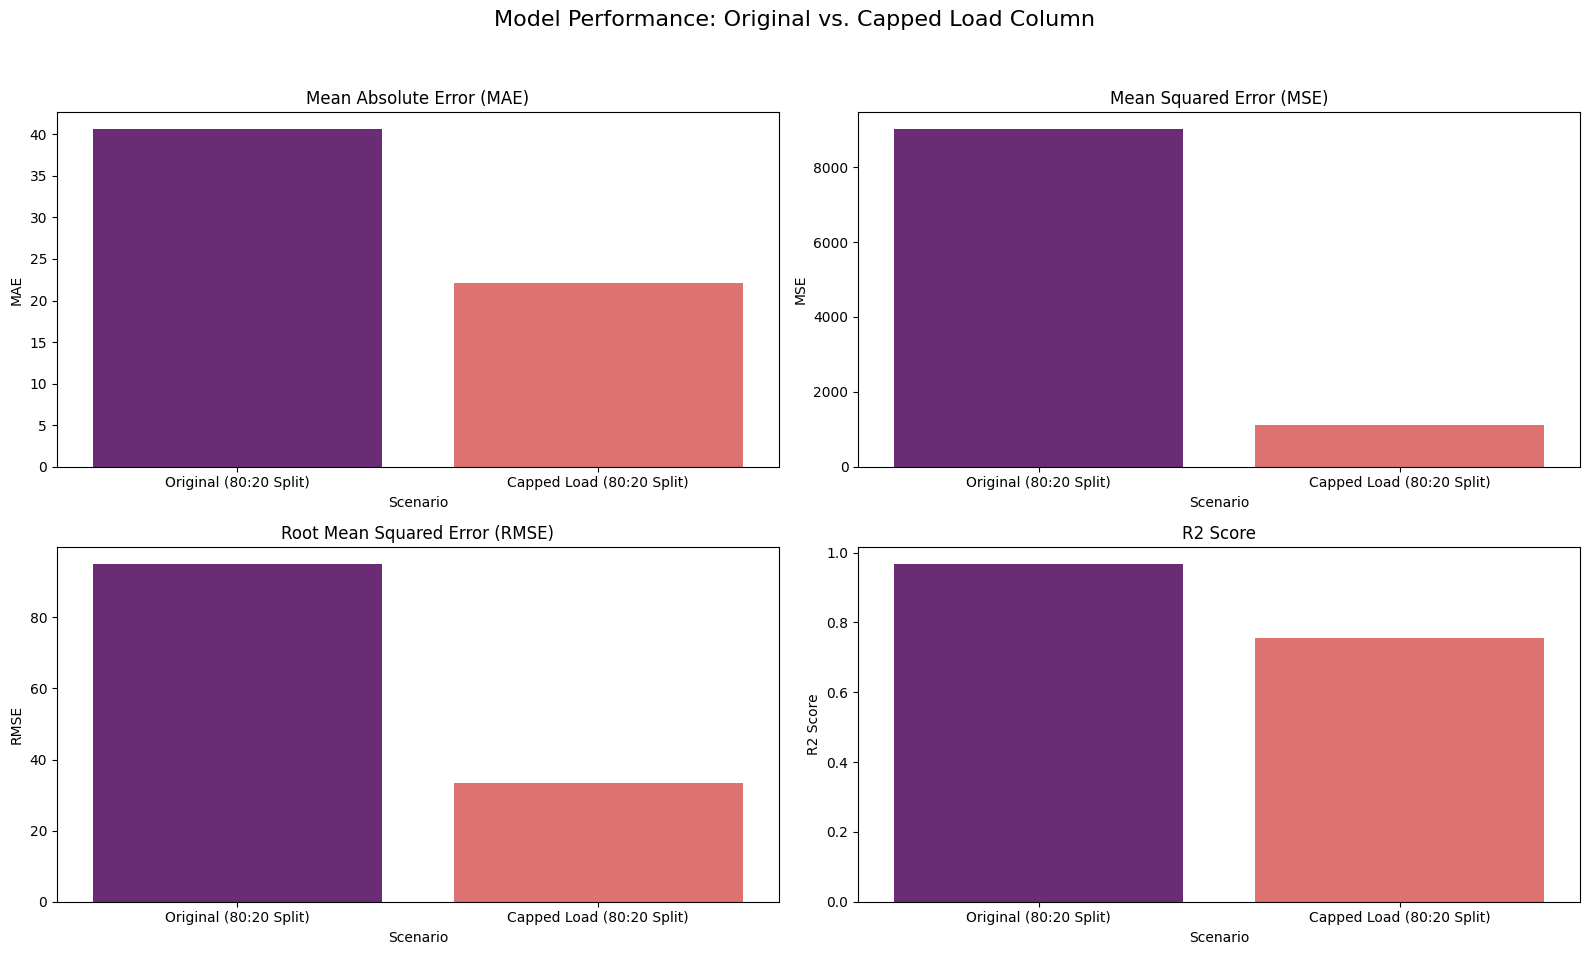

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance: Original vs. Capped Load Column', fontsize=16)

# MAE
sns.barplot(x='Scenario', y='MAE', data=capped_results_df, ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Mean Absolute Error (MAE)')

# MSE
sns.barplot(x='Scenario', y='MSE', data=capped_results_df, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Mean Squared Error (MSE)')

# RMSE
sns.barplot(x='Scenario', y='RMSE', data=capped_results_df, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Root Mean Squared Error (RMSE)')

# R2 Score
sns.barplot(x='Scenario', y='R2 Score', data=capped_results_df, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('R2 Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Create a copy of the DataFrame to apply capping without affecting the original 'df'
df_capped = df.copy()

# Calculate IQR for the 'Load' column
Q1_load = df_capped['Load'].quantile(0.25)
Q3_load = df_capped['Load'].quantile(0.75)
IQR_load = Q3_load - Q1_load

# Define outlier bounds for 'Load' column
lower_bound_load = Q1_load - 1.5 * IQR_load
upper_bound_load = Q3_load + 1.5 * IQR_load

# Apply capping to the 'Load' column
df_capped['Load'] = np.where(df_capped['Load'] < lower_bound_load, lower_bound_load, df_capped['Load'])
df_capped['Load'] = np.where(df_capped['Load'] > upper_bound_load, upper_bound_load, df_capped['Load'])

print(f"Original min Load: {df['Load'].min():.2f}, Original max Load: {df['Load'].max():.2f}")
print(f"Capped min Load: {df_capped['Load'].min():.2f}, Capped max Load: {df_capped['Load'].max():.2f}")

# Redefine features (X_capped) and target (y_capped) from the capped DataFrame
X_capped = df_capped.drop('Load', axis=1)
y_capped = df_capped['Load']

# Perform 80:20 Train-test split on capped data
X_train_capped, X_test_capped, y_train_capped, y_test_capped = train_test_split(X_capped, y_capped, test_size=0.2, random_state=42)

# Apply Feature Scaling on capped data
scaler_capped = StandardScaler()
X_train_scaled_capped = scaler_capped.fit_transform(X_train_capped)
X_test_scaled_capped = scaler_capped.transform(X_test_capped)

# Initialize and train KNN Regressor on capped data
knn_capped = KNeighborsRegressor(n_neighbors=5)
knn_capped.fit(X_train_scaled_capped, y_train_capped)

# Make predictions on the test set of capped data
y_pred_capped = knn_capped.predict(X_test_scaled_capped)

# Model Evaluation for capped data
mae_capped = mean_absolute_error(y_test_capped, y_pred_capped)
mse_capped = mean_squared_error(y_test_capped, y_pred_capped)
rmse_capped = np.sqrt(mse_capped)
r2_capped = r2_score(y_test_capped, y_pred_capped)

# Create a DataFrame to display results for original and capped data
capped_results_df = pd.DataFrame({
    'Scenario': ['Original (80:20 Split)', 'Capped Load (80:20 Split)'],
    'MAE': [mae_80, mae_capped],
    'MSE': [mse_80, mse_capped],
    'RMSE': [rmse_80, rmse_capped],
    'R2 Score': [r2_80, r2_capped]
})

print("\n--- Model Evaluation Results (Original vs. Capped Load) ---")
display(capped_results_df)

Original min Load: 0.10, Original max Load: 14618.87
Capped min Load: 0.10, Capped max Load: 198.15

--- Model Evaluation Results (Original vs. Capped Load) ---


,Scenario,MAE,MSE,RMSE,R2 Score
0,Original (80:20 Split),40.613678,9014.532579,94.944892,0.966933
1,Capped Load (80:20 Split),22.156418,1121.876442,33.494424,0.755038


In [ ]:
print("All identified outlier data points:")
display(outlier_data)

All identified outlier data points:


,Actual_Load,Predicted_Load,Residual
5273,115.868,32.6700,83.1980
1263,422.997,222.4818,200.5152
4707,365.850,496.4862,-130.6362
4907,259.850,145.0052,114.8448
982,210.440,74.5622,135.8778
...,...,...,...
7708,817.040,737.6938,79.3462
2825,348.950,157.3034,191.6466
4708,3261.770,2431.5996,830.1704
798,118.410,17.2160,101.1940


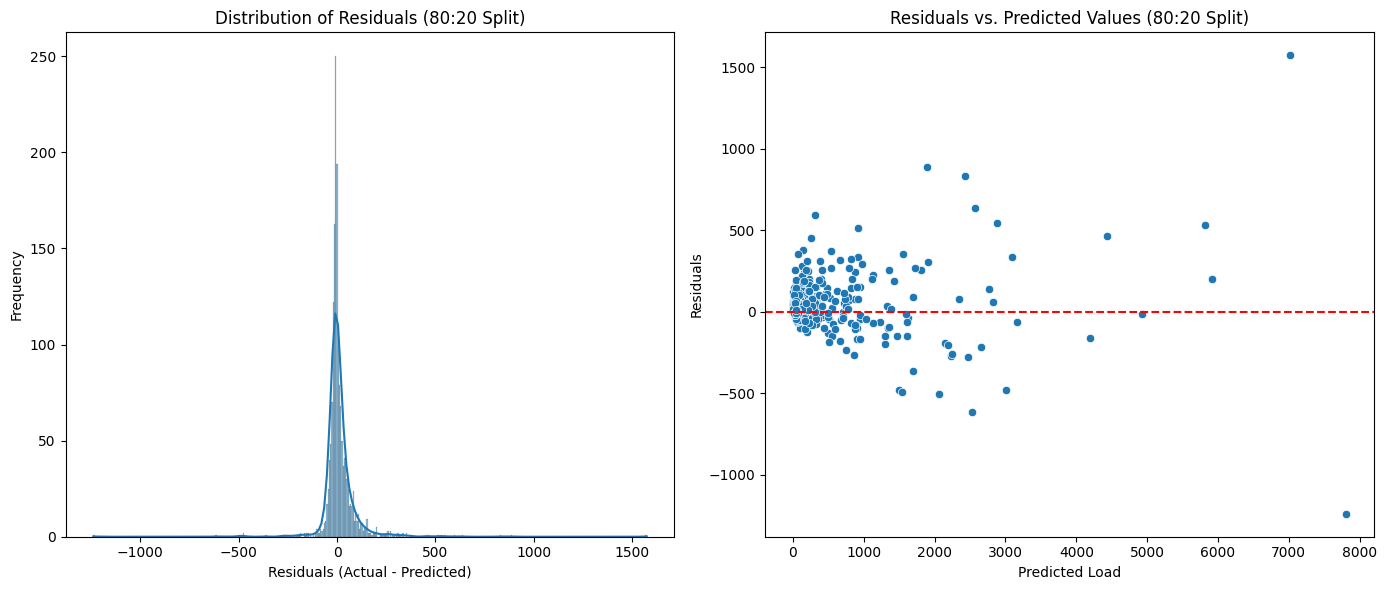

In [ ]:
# Calculate residuals for the 80:20 split
residuals_80 = y_test_80 - y_pred_80

plt.figure(figsize=(14, 6))

# Plot 1: Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals_80, kde=True)
plt.title('Distribution of Residuals (80:20 Split)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')

# Plot 2: Scatter plot of Residuals vs. Predicted values
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_80, y=residuals_80)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (80:20 Split)')
plt.xlabel('Predicted Load')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

In [ ]:
# Data Preprocessing: Encoding categorical features

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Display the first few rows of the preprocessed DataFrame and its info to confirm changes
display(df.head())
df.info()

,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,15,32,117,298,2660,2,0,5,5,84,11.000
1,15,37,116,408,4736,2,0,392,334,44762,872.100
2,15,37,116,408,4805,2,0,492,431,31931,568.730
3,15,37,116,408,5152,2,0,458,407,28871,657.578
4,15,37,116,408,5576,2,0,326,262,111598,2199.410


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   int64  
 1   Division        8335 non-null   int64  
 2   SubDivision     8335 non-null   int64  
 3   Section         8335 non-null   int64  
 4   Area            8335 non-null   int64  
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   int64  
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(10)
memory usage: 716.4 KB


In [ ]:
# Define features (X) and target (y)
X = df.drop('Load', axis=1)  # All columns except 'Load' are features
y = df['Load']               # 'Load' is the target variable

# ----------------------------------------------------------------
# Train-test split (80:20 ratio)
# ----------------------------------------------------------------
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------------------------------------------
# Train-test split (70:30 ratio)
# ----------------------------------------------------------------
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

# ----------------------------------------------------------------
# Feature Scaling
# ----------------------------------------------------------------
scaler = StandardScaler()

# For 80:20 split
X_train_scaled_80 = scaler.fit_transform(X_train_80)
X_test_scaled_80 = scaler.transform(X_test_80)

# For 70:30 split
X_train_scaled_70 = scaler.fit_transform(X_train_70)
X_test_scaled_70 = scaler.transform(X_test_70)

print("Data split and scaled successfully for both 80:20 and 70:30 ratios.")
print(f"Shape of X_train_scaled_80: {X_train_scaled_80.shape}")
print(f"Shape of X_test_scaled_80: {X_test_scaled_80.shape}")
print(f"Shape of X_train_scaled_70: {X_train_scaled_70.shape}")
print(f"Shape of X_test_scaled_70: {X_test_scaled_70.shape}")

Data split and scaled successfully for both 80:20 and 70:30 ratios.
Shape of X_train_scaled_80: (6668, 10)
Shape of X_test_scaled_80: (1667, 10)
Shape of X_train_scaled_70: (5834, 10)
Shape of X_test_scaled_70: (2501, 10)


In [ ]:
# Initialize and train KNN Regressor for 80:20 split
knn_80 = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a default
knn_80.fit(X_train_scaled_80, y_train_80)

# Make predictions on the test set for 80:20 split
y_pred_80 = knn_80.predict(X_test_scaled_80)

# Initialize and train KNN Regressor for 70:30 split
knn_70 = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a default
knn_70.fit(X_train_scaled_70, y_train_70)

# Make predictions on the test set for 70:30 split
y_pred_70 = knn_70.predict(X_test_scaled_70)

print("KNN models trained and predictions made for both splits.")

KNN models trained and predictions made for both splits.


In [ ]:
# Model Evaluation for 80:20 split
mae_80 = mean_absolute_error(y_test_80, y_pred_80)
mse_80 = mean_squared_error(y_test_80, y_pred_80)
rmse_80 = np.sqrt(mse_80)
r2_80 = r2_score(y_test_80, y_pred_80)

# Model Evaluation for 70:30 split
mae_70 = mean_absolute_error(y_test_70, y_pred_70)
mse_70 = mean_squared_error(y_test_70, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_70, y_pred_70)

# Create a DataFrame to display results
results_df = pd.DataFrame({
    'Split Ratio': ['80:20', '70:30'],
    'MAE': [mae_80, mae_70],
    'MSE': [mse_80, mse_70],
    'RMSE': [rmse_80, rmse_70],
    'R2 Score': [r2_80, r2_70]
})

print("\n--- Model Evaluation Results ---")
display(results_df)


--- Model Evaluation Results ---


,Split Ratio,MAE,MSE,RMSE,R2 Score
0,80:20,40.613678,9014.532579,94.944892,0.966933
1,70:30,40.786249,8440.138601,91.870227,0.965785


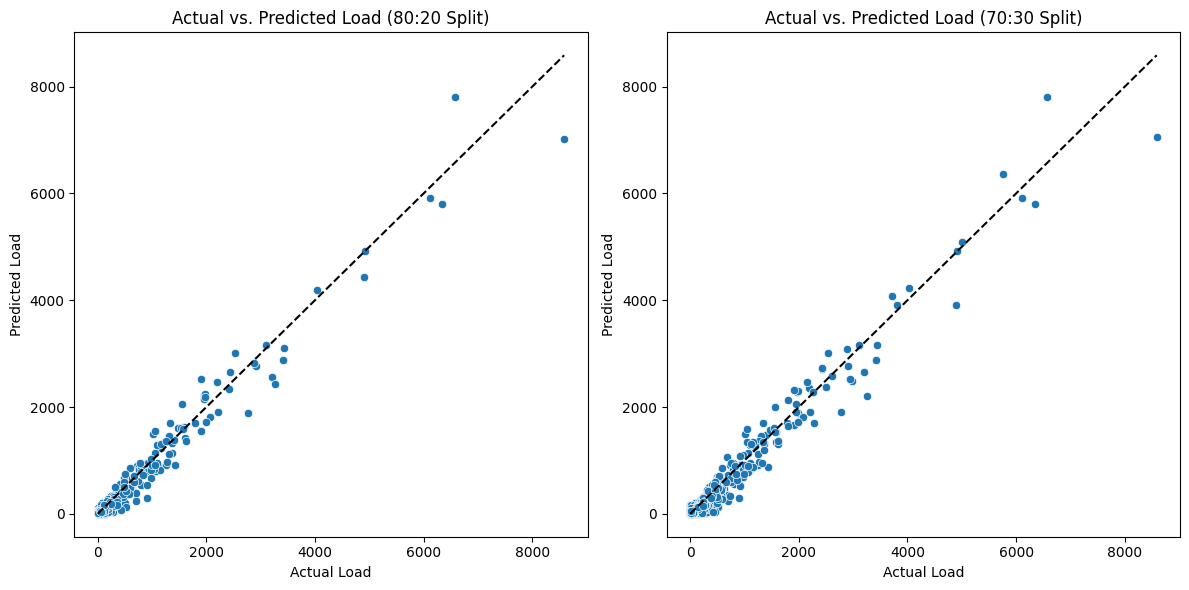

In [ ]:
# Visualization of Actual vs. Predicted values for 80:20 split
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_80, y=y_pred_80)
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs. Predicted Load (80:20 Split)')
plt.plot([y_test_80.min(), y_test_80.max()], [y_test_80.min(), y_test_80.max()], 'k--') # Diagonal line

# Visualization of Actual vs. Predicted values for 70:30 split
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_70, y=y_pred_70)
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs. Predicted Load (70:30 Split)')
plt.plot([y_test_70.min(), y_test_70.max()], [y_test_70.min(), y_test_70.max()], 'k--') # Diagonal line

plt.tight_layout()
plt.show()

In [ ]:
# Display data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB
